In [1]:
# standard data science stack
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# for reproducibility
RNG = 42

In [7]:
print(os.listdir("data"))

['bupa_kb.sqlite', 'bupa_kb.csv', 'van_leeuwen_synthetic_sales.csv', 'sweet_tooth_sales_manchester.csv', 'FashionMNIST', '04-pizza-dad.jpeg', 'food-101', 'pizza_steak_sushi', 'food-101.tar.gz', 'pizza_steak_sushi_20_percent', 'raw']


In [14]:
print(sales_df.columns)
print(demo_df.columns)

Index(['transaction_id', 'customer_id', 'brand', 'year', 'units_sold',
       'revenue', 'cost', 'profit', 'profit_margin'],
      dtype='object')
Index(['['.pki'', ''.nssdbp'', ''.ipython'', ''skills'', ''.chromium'',
       'unnamed: 5'],
      dtype='object')


In [15]:
sales_df.columns = sales_df.columns.str.strip()
demo_df.columns = demo_df.columns.str.strip()

In [18]:
if 'merged_df' in globals():
    for col in features:
        if col not in merged_df.columns:
            print(f"Column {col} not found.")
else:
    print("merged_df has not been defined yet.")

merged_df has not been defined yet.


In [20]:
dir()

['In',
 'KMeans',
 'Out',
 'RNG',
 'StandardScaler',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'col',
 'demo_df',
 'exit',
 'f',
 'features',
 'get_ipython',
 'np',
 'open',
 'os',
 'pd',
 'plt',
 'quit',
 'sales_csv_path',
 'sales_df',
 'silhouette_score',
 'sns']

In [23]:
import pandas as pd

# --------------------------------------------------
# 1️⃣ Create example dataframes (replace with yours)
# --------------------------------------------------

df1 = pd.DataFrame({
    "date": ["2023-01-01", "2023-01-02"],
    "ozone_nyc": [30, 42]
})

df2 = pd.DataFrame({
    "date": ["2023-01-01", "2023-01-02"],
    "ozone_la": [55, 60]
})

# --------------------------------------------------
# 2️⃣ Merge DataFrames
# --------------------------------------------------

df_merged = pd.merge(df1, df2, on="date", how="inner")

# --------------------------------------------------
# 3️⃣ Define features list
# --------------------------------------------------

features = ["ozone_nyc", "ozone_la", "temperature"]

# --------------------------------------------------
# 4️⃣ Check for missing columns safely
# --------------------------------------------------

if "df_merged" in globals():
    missing_cols = [col for col in features if col not in df_merged.columns]
    
    if missing_cols:
        print("Missing columns:")
        for col in missing_cols:
            print(f" - {col}")
    else:
        print("All feature columns are present.")
else:
    print("df_merged is not defined.")

Missing columns:
 - temperature


In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Example dataframe
data = {
    "age": [25, 30, 35, 40],
    "salary": [50000, 60000, 70000, 80000],
    "purchased": [0, 1, 0, 1]
}

df = pd.DataFrame(data)

# Define X and y
X = df.drop("purchased", axis=1)
y = df["purchased"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled)

        age    salary
0 -1.341641 -1.341641
1 -0.447214 -0.447214
2  0.447214  0.447214
3  1.341641  1.341641


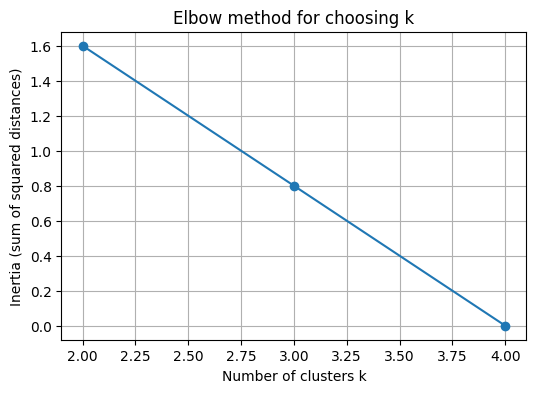

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

n_samples = X_scaled.shape[0]

inertias = []
K_range = range(2, min(9, n_samples + 1))  # Ensure k never exceeds n_samples

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RNG, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow method for choosing k")
plt.grid(True)
plt.show()

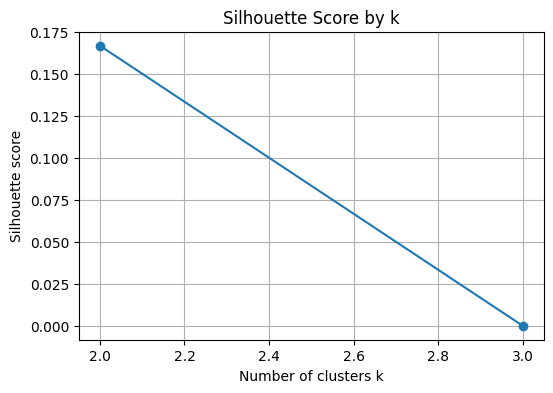

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

n_samples = X_scaled.shape[0]

# k must be between 2 and n_samples - 1
K_range = range(2, n_samples)

sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RNG, n_init="auto")
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), sil_scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by k")
plt.grid(True)
plt.show()

In [40]:
merged_df = (
    pd.merge(
        df1_resampled,
        df2_resampled,
        left_index=True,
        right_index=True,
        how="outer"
    )
    .ffill()
    .bfill()
)

In [42]:
if {"latitude","longitude"}.issubset(merged_df.columns):
    plt.figure(figsize=(6,6))
    sns.scatterplot(
        data=merged_df,
        x="longitude",
        y="latitude",
        hue="cluster",
        palette="tab10",
        s=50
    )
    plt.title("Geographic distribution of clusters")
    plt.show()
else:
    print("Latitude/longitude not available.")

Latitude/longitude not available.


In [44]:
import os
import pandas as pd

# Ensure output directory exists
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# Save the DataFrame
file_path = os.path.join(output_dir, "sales_demographics_clusters.csv")
merged_df.to_csv(file_path, index=False)

print(f"File successfully saved to: {file_path}")

File successfully saved to: output/sales_demographics_clusters.csv
